#**MMDA Project: linear and ensemble models training + evaluation**

In [1]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from nltk.corpus import words
from IPython.display import clear_output

RANDOM_STATE = 42
TEST_SIZE = 0.2
ENGLISH_QUOTA_THRESHOLD = 0.8

import warnings
warnings.filterwarnings('ignore')

In [2]:
import nltk
nltk.download('words', quiet=True)

True

### Load data and split it:

In [21]:
data = pd.read_csv("/content/cyberbullying_tweets.csv")

data.dropna(inplace=True)

ENGLISH_WORDS = set(words.words())

def english_quota(text):
    if not isinstance(text, str):
        return 0
    word_list = re.findall(r'\b\w+\b', text.lower())
    if not word_list:
        return 0
    english_count = sum(1 for w in word_list if w in ENGLISH_WORDS)
    return english_count / len(word_list)

data["english_quota"] = data["tweet_text"].apply(english_quota)
data = data[data["english_quota"] >= ENGLISH_QUOTA_THRESHOLD].copy()

In [22]:
# deduplication

data["tweet_text_dedup_key"] = data["tweet_text"].astype(str).str.strip().str.lower()
before_dedup = len(data)

# count labels for each duplicate text
label_counts = data.groupby(["tweet_text_dedup_key", "cyberbullying_type"]).size().reset_index(name="count")

# keep the majority label for every duplicated text
label_counts["max_count"] = label_counts.groupby("tweet_text_dedup_key")["count"].transform("max")
majority_labels = label_counts[label_counts["count"] == label_counts["max_count"]].copy()

# remove ambiguous duplicate groups where two or more labels are tied
tie_counts = majority_labels.groupby("tweet_text_dedup_key")["cyberbullying_type"].nunique()
non_ambiguous_keys = tie_counts[tie_counts == 1].index

majority_labels = majority_labels[
    majority_labels["tweet_text_dedup_key"].isin(non_ambiguous_keys)
][["tweet_text_dedup_key", "cyberbullying_type"]]

majority_labels = majority_labels.rename(
    columns={"cyberbullying_type": "majority_label"}
)

# keep one representative tweet for each non-ambiguous text
data = ( data
        .merge(majority_labels, on="tweet_text_dedup_key", how="inner")
        .drop_duplicates(subset="tweet_text_dedup_key", keep="first")
        .copy()
       )

# use the majority label as the final label
data["cyberbullying_type"] = data["majority_label"]

data = data.drop(columns=["majority_label"])
data = data.reset_index(drop=True)
data["row_id"] = data.index

after_dedup = len(data)

print("Rows after filtering and deduplication:", after_dedup)
print("Removed duplicate/ambiguous rows:", before_dedup - after_dedup)

# label encoding
le = LabelEncoder()
data["label"] = le.fit_transform(data["cyberbullying_type"])

id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in id2label.items()}

print("Classes:", id2label, "\n")
print(data["cyberbullying_type"].value_counts())

Rows after filtering and deduplication: 21117
Removed duplicate/ambiguous rows: 1310
Classes: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'} 

cyberbullying_type
age                    5952
gender                 3663
religion               3658
ethnicity              3403
other_cyberbullying    2331
not_cyberbullying      2110
Name: count, dtype: int64


In [23]:
# split data, the same split will be used with transformers
train_idx, test_idx = train_test_split(
    data["row_id"].values,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data["label"].values
)

train_df = data[data["row_id"].isin(train_idx)].copy()
test_df = data[data["row_id"].isin(test_idx)].copy()

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 16893
Test size:  4224


### Data preprocessing and feature engineering:

I preprocessed data using the class TextPreprocessor from the file MMDA_Project.ipynb:

In [6]:
%run '/content/MMDA_Project.ipynb'
clear_output()

In [24]:
preprocessing_config = {
    "lowercase": True,
    "remove_stopwords": True,
    "use_stemming": False,
    "use_lemmatization": True,
    "replace_urls": True,
    "replace_mentions": True,
    "normalize_mojibake": True,
    "remove_duplicates": False,
    "min_word_length": 2
}

preprocessor = TextPreprocessor(**preprocessing_config)

train_df["tokens"] = train_df["tweet_text"].apply(preprocessor.preprocess)
test_df["tokens"] = test_df["tweet_text"].apply(preprocessor.preprocess)

# remove empty texts after preprocessing
train_df = train_df[train_df["tokens"].apply(len) > 0].copy()
test_df = test_df[test_df["tokens"].apply(len) > 0].copy()

y_train = train_df["label"].values
y_test = test_df["label"].values

print("Train after removing empty tweets:", len(train_df))
print("Test after removing empty tweets:", len(test_df))

Train after removing empty tweets: 16886
Test after removing empty tweets: 4224


In [25]:
# final cleaned data after deduplication, filtering, and empty-tweet removal
final_cleaned_data = pd.concat([train_df, test_df], axis=0).sort_values("row_id")

final_cleaned_data.to_csv("cleaned_deduplicated_tweets.csv", index=False)
final_cleaned_data[["row_id", "cyberbullying_type"]].to_csv("cleaned_row_ids.csv", index=False)

train_df[["row_id", "cyberbullying_type"]].to_csv("train_final_row_ids.csv", index=False)
test_df[["row_id", "cyberbullying_type"]].to_csv("test_final_row_ids.csv", index=False)

In [26]:
feature_engineer = FeatureEngineer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=3,
    max_df=0.9
)

# TF-IDF
X_train_tfidf = feature_engineer.extract_tfidf_features(train_df["tokens"], fit=True)
X_test_tfidf = feature_engineer.extract_tfidf_features(test_df["tokens"], fit=False)

# meta features
train_meta_df = train_df[["tokens"]].copy()
test_meta_df = test_df[["tokens"]].copy()

X_train_meta = feature_engineer.extract_meta_features(train_meta_df, "tokens")
X_test_meta = feature_engineer.extract_meta_features(test_meta_df, "tokens")

# train_meta_df = train_df[["tweet_text"]].copy()
# test_meta_df = test_df[["tweet_text"]].copy()

# X_train_meta = feature_engineer.extract_meta_features(train_meta_df, "tweet_text")
# X_test_meta = feature_engineer.extract_meta_features(test_meta_df, "tweet_text")

X_train_meta["english_quota"] = train_df["english_quota"].values
X_test_meta["english_quota"] = test_df["english_quota"].values

# scale numeric meta features
meta_scaler = StandardScaler(with_mean=False)

X_train_meta_scaled = meta_scaler.fit_transform(csr_matrix(X_train_meta.values))
X_test_meta_scaled = meta_scaler.transform(csr_matrix(X_test_meta.values))

# TF-IDF + meta features
X_train = hstack([X_train_tfidf, X_train_meta_scaled]).tocsr()
X_test = hstack([X_test_tfidf, X_test_meta_scaled]).tocsr()

print("TF-IDF train shape:", X_train_tfidf.shape)
print("Meta train shape:", X_train_meta.shape)
print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)

TF-IDF train shape: (16886, 16689)
Meta train shape: (16886, 10)
Final train shape: (16886, 16699)
Final test shape: (4224, 16699)


### Training and evaluation:

In [27]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    result = {
        "model": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {precision:.4f}")
    print(f"Macro recall:    {recall:.4f}")
    print(f"Macro F1:        {f1:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=4,
        zero_division=0
    ))

    return result, y_pred

First, let's train simple linear models:

In [28]:
linear_models = {
    "Logistic Regression": LogisticRegression(
        C=4.0,
        max_iter=2000,
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        multi_class="multinomial"
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE
    ),

    "SGD Linear SVM": SGDClassifier(
        loss="hinge",
        alpha=1e-5,
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

all_results = []
all_predictions = {}

for name, model in linear_models.items():
    result, pred = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        name
    )
    all_results.append(result)
    all_predictions[name] = pred

Logistic Regression
Accuracy:        0.8911
Macro precision: 0.8530
Macro recall:    0.8471
Macro F1:        0.8461

                     precision    recall  f1-score   support

                age     0.9743    0.9882    0.9812      1190
          ethnicity     0.9867    0.9838    0.9853       681
             gender     0.9381    0.8690    0.9023       733
  not_cyberbullying     0.6502    0.4976    0.5638       422
other_cyberbullying     0.5931    0.7725    0.6710       466
           religion     0.9753    0.9713    0.9733       732

           accuracy                         0.8911      4224
          macro avg     0.8530    0.8471    0.8461      4224
       weighted avg     0.8958    0.8911    0.8909      4224

Linear SVM
Accuracy:        0.8909
Macro precision: 0.8461
Macro recall:    0.8445
Macro F1:        0.8441

                     precision    recall  f1-score   support

                age     0.9718    0.9857    0.9787      1190
          ethnicity     0.9854    0.988

Now let's train ensemble models, starting with voting classifier over linear models:

In [29]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(
            C=4.0,
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            multi_class="multinomial"
        )),
        ("svc", LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE
        )),
        ("sgd", SGDClassifier(
            loss="hinge",
            alpha=1e-5,
            max_iter=1000,
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ],
    voting="hard",
    n_jobs=-1
)

result, pred = evaluate_model(
    voting_clf,
    X_train,
    y_train,
    X_test,
    y_test,
    "Voting Ensemble: LR + SVC + SGD"
)

all_results.append(result)
all_predictions["Voting Ensemble: LR + SVC + SGD"] = pred

Voting Ensemble: LR + SVC + SGD
Accuracy:        0.8911
Macro precision: 0.8558
Macro recall:    0.8458
Macro F1:        0.8431

                     precision    recall  f1-score   support

                age     0.9727    0.9891    0.9808      1190
          ethnicity     0.9825    0.9897    0.9861       681
             gender     0.9396    0.8704    0.9037       733
  not_cyberbullying     0.6727    0.4384    0.5308       422
other_cyberbullying     0.5850    0.8197    0.6828       466
           religion     0.9820    0.9672    0.9745       732

           accuracy                         0.8911      4224
          macro avg     0.8558    0.8458    0.8431      4224
       weighted avg     0.8974    0.8911    0.8894      4224



Now we try to train tree-based ensemble models. Because of sparsity TF-IDF, we reduce TF-IDF with TruncatedSVD, then concatenate the meta-features.

In [30]:
N_COMPONENTS = 300

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# dense meta-features
X_train_meta_dense = X_train_meta_scaled.toarray()
X_test_meta_dense = X_test_meta_scaled.toarray()

# reduced TF-IDF + raw meta-features
X_train_dense = np.hstack([X_train_svd, X_train_meta_dense])
X_test_dense = np.hstack([X_test_svd, X_test_meta_dense])

print("Dense train shape:", X_train_dense.shape)
print("Dense test shape:", X_test_dense.shape)
print("Explained variance by SVD:", svd.explained_variance_ratio_.sum())

Dense train shape: (16886, 310)
Dense test shape: (4224, 310)
Explained variance by SVD: 0.26861177201745084


In [31]:
tree_ensemble_models = {
    "Random Forest on SVD features": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "Extra Trees on SVD features": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "HistGradientBoosting on SVD features": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

for name, model in tree_ensemble_models.items():
    result, pred = evaluate_model(
        model,
        X_train_dense,
        y_train,
        X_test_dense,
        y_test,
        name
    )
    all_results.append(result)
    all_predictions[name] = pred

Random Forest on SVD features
Accuracy:        0.8755
Macro precision: 0.8367
Macro recall:    0.8235
Macro F1:        0.8222

                     precision    recall  f1-score   support

                age     0.9560    0.9866    0.9711      1190
          ethnicity     0.9683    0.9853    0.9767       681
             gender     0.9337    0.8649    0.8980       733
  not_cyberbullying     0.6486    0.3981    0.4934       422
other_cyberbullying     0.5413    0.7446    0.6269       466
           religion     0.9724    0.9617    0.9670       732

           accuracy                         0.8755      4224
          macro avg     0.8367    0.8235    0.8222      4224
       weighted avg     0.8805    0.8755    0.8729      4224

Extra Trees on SVD features
Accuracy:        0.8733
Macro precision: 0.8345
Macro recall:    0.8187
Macro F1:        0.8193

                     precision    recall  f1-score   support

                age     0.9262    0.9908    0.9574      1190
          et

### Results and comparison:

In [32]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

results_df.round(4)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Logistic Regression,0.8911,0.8530,0.8471,0.8461
1,Linear SVM,0.8909,0.8461,0.8445,0.8441
2,Voting Ensemble: LR + SVC + SGD,0.8911,0.8558,0.8458,0.8431
3,HistGradientBoosting on SVD features,0.8857,0.8418,0.8390,0.8383
4,Random Forest on SVD features,0.8755,0.8367,0.8235,0.8222
5,SGD Linear SVM,0.8783,0.8650,0.8308,0.8197
6,Extra Trees on SVD features,0.8733,0.8345,0.8187,0.8193


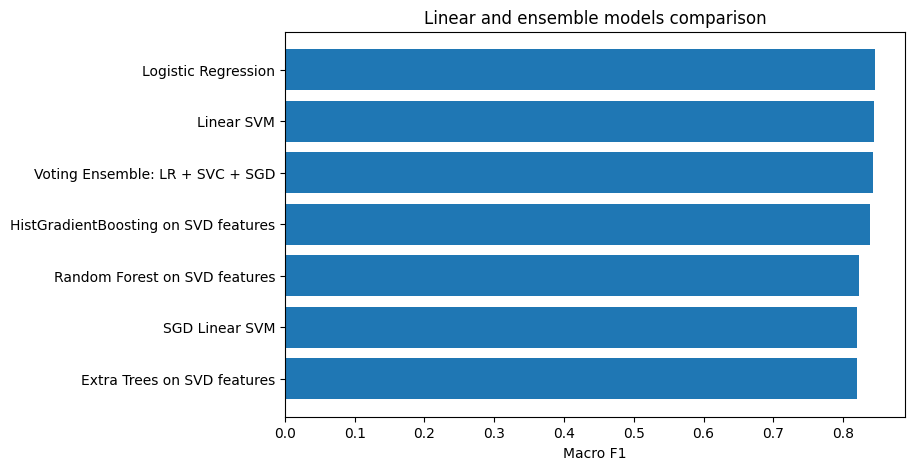

In [33]:
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Linear and ensemble models comparison")
plt.gca().invert_yaxis()
plt.show()

As we can see, among the evaluated models, Logistic Regression achieved the highest test-set macro F1. The second highest test-set macro F1 was achieved by linear SVM, which metric results not far away from LR.

Now let's look at the confusion matrix of the best evaluated model:

Model name: Logistic Regression


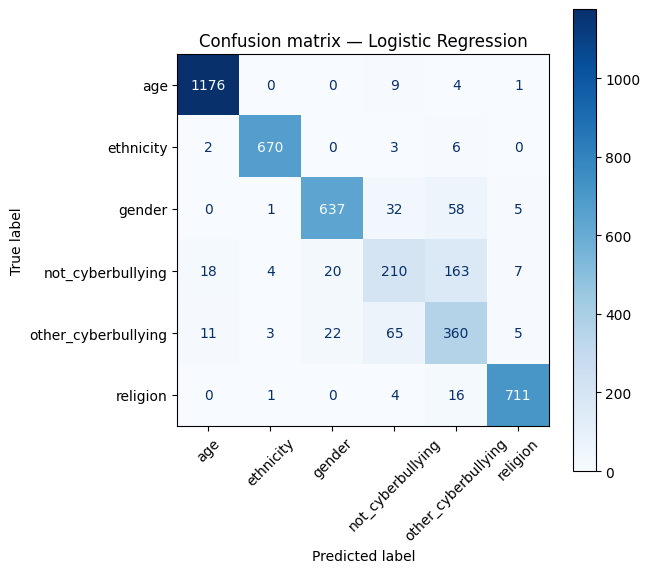

In [34]:
best_model_name = results_df.loc[0, "model"]
best_pred = all_predictions[best_model_name]

print("Model name:", best_model_name)

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title(f"Confusion matrix — {best_model_name}")
plt.show()

Now let's look at the feature importance for the Logistic Regression model:

In [46]:
tfidf_feature_names = feature_engineer.tfidf_vectorizer.get_feature_names_out()
meta_feature_names = X_train_meta.columns.to_numpy()
all_feature_names = np.concatenate([tfidf_feature_names, meta_feature_names])

def plot_top_features(feature_names, importances, title, top_n=25):
    top_idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(7, 5))
    plt.barh(feature_names[top_idx], importances[top_idx])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

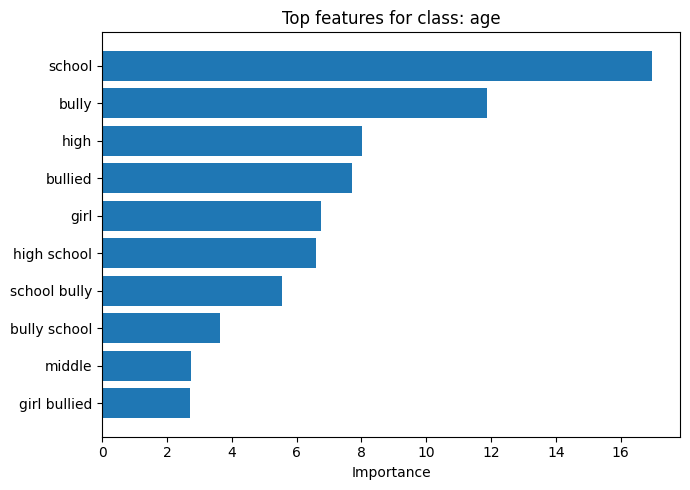

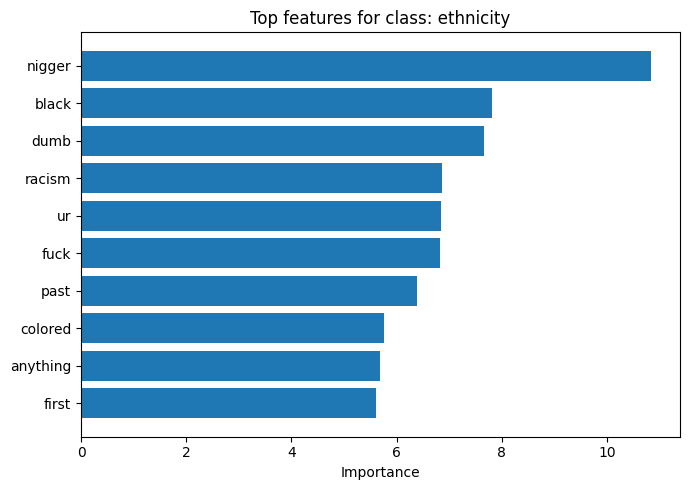

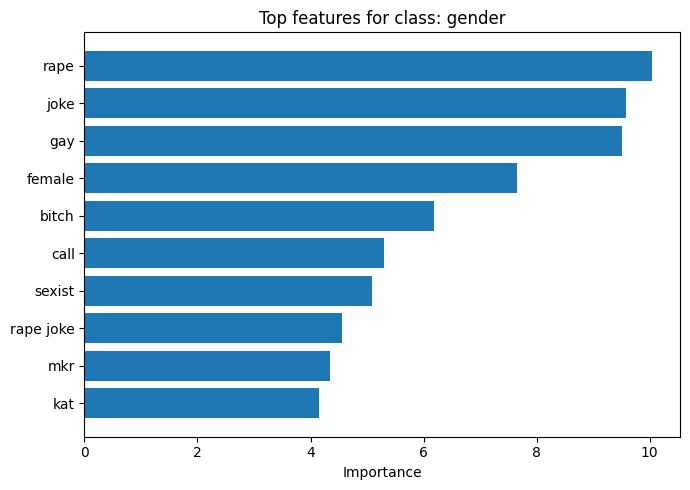

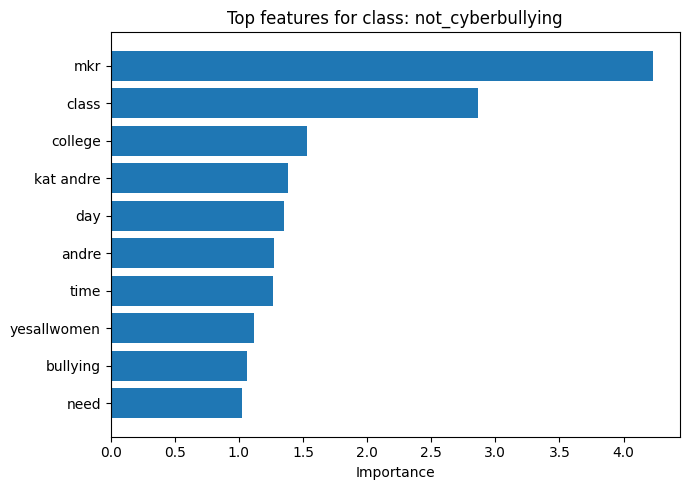

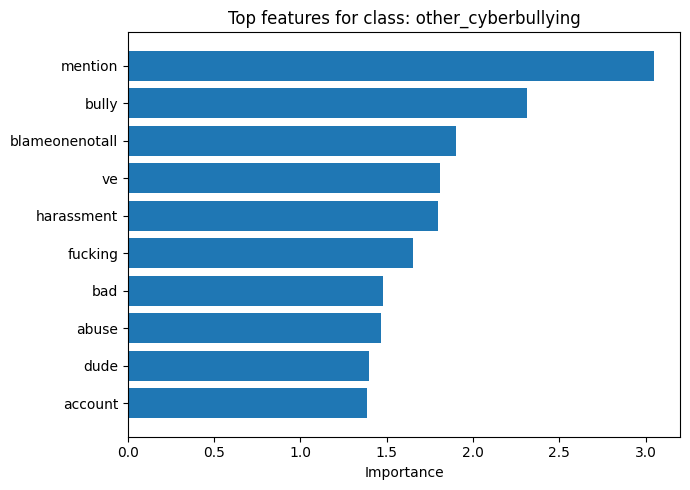

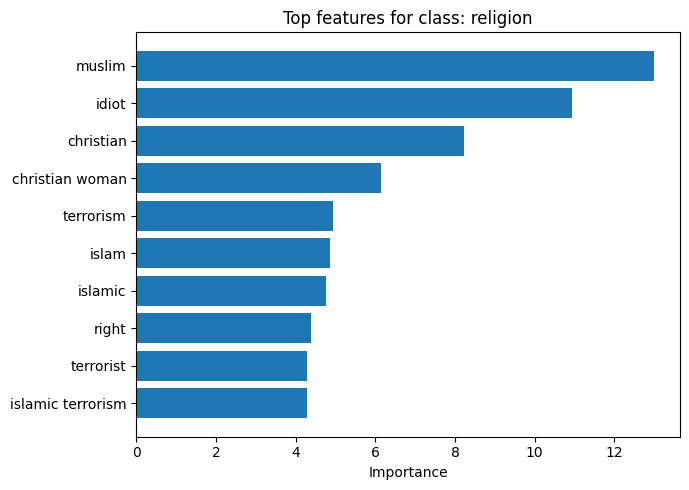

In [47]:
best_model = LogisticRegression(C=4.0,
                                max_iter=2000,
                                solver="saga",
                                n_jobs=-1,
                                random_state=RANDOM_STATE,
                                multi_class="multinomial"
                                )
best_model.fit(X_train, y_train)

coef = best_model.coef_

for class_id, class_name in enumerate(le.classes_):
    class_importance = coef[class_id]
    top_idx = np.argsort(class_importance)[-10:][::-1]

    plot_top_features(
        all_feature_names,
        class_importance,
        f"Top features for class: {class_name}",
        top_n=10
    )

### Error analysis:

In [35]:
best_predictions_df = pd.DataFrame({
    "row_id": test_df["row_id"].values,
    "y_true": y_test,
    "y_pred": best_pred,
    "true_label": le.inverse_transform(y_test),
    "pred_label": le.inverse_transform(best_pred)
})

best_predictions_df.to_csv("linear_ensemble_best_predictions.csv", index=False)
best_predictions_df.head()

,row_id,y_true,y_pred,true_label,pred_label
0,1,3,2,not_cyberbullying,gender
1,3,3,4,not_cyberbullying,other_cyberbullying
2,5,3,3,not_cyberbullying,not_cyberbullying
3,11,3,4,not_cyberbullying,other_cyberbullying
4,12,3,4,not_cyberbullying,other_cyberbullying


In [36]:
errors_df = best_predictions_df[best_predictions_df["y_true"] != best_predictions_df["y_pred"]].copy()
errors_df = errors_df.merge(test_df[["row_id", "tweet_text"]], on="row_id", how="left")

print("Number of errors:", len(errors_df))
errors_df.head()

Number of errors: 460


,row_id,y_true,y_pred,true_label,pred_label,tweet_text
0,1,3,2,not_cyberbullying,gender,Karma. I hope it bites Kat on the butt. She is...
1,3,3,4,not_cyberbullying,other_cyberbullying,"I still have Jack, Amsterdam, Ciroc, Crown, Bu..."
2,11,3,4,not_cyberbullying,other_cyberbullying,no one ever help.me like my bully @AlwaysVero_...
3,12,3,4,not_cyberbullying,other_cyberbullying,You look like a gypsy. Sorry I'm not sorry.
4,15,3,4,not_cyberbullying,other_cyberbullying,@Bahai144 ROFLMAO. So all this time I've been...


In [37]:
error_summary = errors_df.groupby(["true_label", "pred_label"]).size().reset_index(name="count").sort_values("count", ascending=False)
error_summary.head()

,true_label,pred_label,count
13,not_cyberbullying,other_cyberbullying,163
18,other_cyberbullying,not_cyberbullying,65
8,gender,other_cyberbullying,58
7,gender,not_cyberbullying,32
17,other_cyberbullying,gender,22


Logistic Regression does not classify correctly 460 tweets.